In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties

/Applications/anaconda3/envs/spyder-5.4.3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# VCM CH4 FaIR analysis

This analysis estimates the temperature effects of retired VCM credits associated with methane mitigation. The primary analysis uses the lower-bound methane credit time series. CH4 project reductions are assigned according to the vintage of retired credits (`retired_vintage_lower`), representing when the underlying mitigation occurred. Associated justified CO2 emissions are assigned according to the actual credit retirement year (`retired_year_lower`), representing when the offset was used.

The previous assumption that retirement year equals vintage year is retained as a timing sensitivity test. We also evaluate an upper-bound methane-associated credit estimate using `retired_vintage_upper` and `retired_year_upper`. The upper bound scenario assumes that all credited mitigation is CH4, although some projects included in the upper classification liekly involve other gases.

The main accounting case uses IPCC AR6 non-fossil CH4 GWP100 = 27.0. GWP and GTP alternatives are treated as sensitivity tests.

The climate analysis uses the full 841-member calibrated and constrained FaIR ensemble from calibration v1.4.1 with SSP1-2.6 as the common baseline (Hughes et al., preprint). To better reproduce accepted CH4 behavior, SSP1-2.6 background CH4 emissions and baseline lifetime are scaled, while the remaining CH4 lifetime sensitivities use calibration v1.4.0 values. The central trajectory is the median across the 841 paired ensemble responses.

In [2]:
# ----------------------------
# inputs
# ----------------------------

VCM_FILE = "../timeseries-data/output-data/vcm_methane_credit_timeseries.csv"

# calibration v1.4.1 provides the constrained 841-member climate/carbon-cycle ensemble
FAIR_PARAMS_FILE = "../timeseries-data/input-data/fair/calibrated_constrained_parameters_calibration1.4.1.csv"

# full species parameters corresponding to calibration v1.4.1
FAIR_SPECIES_CONFIG_FILE = "../timeseries-data/input-data/fair/species_configs_properties_calibration1.4.1.csv"

# Hughes et al. (2026) baseline
BASELINE_SCENARIO = "ssp126"
START_YEAR = 1750
END_YEAR = 2200
ANALYSIS_START = 1996

# methane tuning
CH4_BASE_LIFETIME_YR = 8.7
CH4_EMISSIONS_SCALE = 1.25

# IPCC AR6 non-fossil CH4 GWP100 and sensitivity values
EQUIV_METRICS = {"GWP100": 27.0, "GWP20": 84, "GWP500": 8, "GTP20": 67, "GTP50": 14, "GTP100": 4,}

## 01 - Load retired CH4-associated credits by vintage year and retirement year

In [3]:
# ----------------------------
# load VCM data
# ----------------------------

df = pd.read_csv(VCM_FILE).sort_values("year").fillna(0)

required = ["year",
    "retired_vintage_lower", "retired_year_lower",
    "retired_vintage_upper", "retired_year_upper",]

missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

vcm = df.set_index("year")

retired_vintage = vcm["retired_vintage_lower"].astype(float)
retired_year = vcm["retired_year_lower"].astype(float)

retired_vintage_upper = vcm["retired_vintage_upper"].astype(float)
retired_year_upper = vcm["retired_year_upper"].astype(float)

assert np.isclose(retired_vintage.sum(), retired_year.sum())
assert np.isclose(retired_vintage_upper.sum(), retired_year_upper.sum())

print(f"Lower-bound retired credits: {retired_vintage.sum()/1e6:,.2f} MtCO2e")
print(f"Upper-bound retired credits: {retired_vintage_upper.sum()/1e6:,.2f} MtCO2e")
print(f"Year range: {int(vcm.index.min())}-{int(vcm.index.max())}")

Lower-bound retired credits: 65.75 MtCO2e
Upper-bound retired credits: 157.55 MtCO2e
Year range: 1996-2026


## 02 - Convert credits to physical project and justified-emissions fluxes

For the primary lower-bound GWP100 analysis:
- CH4 project reductions = `retired_vintage_lower / 27`, assigned by vintage year
- justified CO2 emissions = `retired_year_lower`, assigned by actual retirement year

The previous timing assumption is retained as a sensitivity test by assigning both CH4 project reductions and justified CO2 emissions according to `retired_vintage_lower`.

The upper-bound analysis uses the same timing treatment:
- CH4 project reductions = `retired_vintage_upper / 27`, assigned by vintage year
- justified CO2 emissions = `retired_year_upper`, assigned by actual retirement year

The upper-bound calculation assumes that all credited mitigation represented by the upper classification is CH4 as a sensitivity test.

In [4]:
# ----------------------------
# build annual perturbation fluxes
# ----------------------------

def make_fluxes(metric_value, project_credits, justified_credits):
    return pd.DataFrame(index=vcm.index, data={
        "ch4_flux": -project_credits / metric_value,  # tonnes CH4
        "co2_flux": justified_credits,                # tonnes CO2
    })

# primary lower-bound analysis
fluxes = {metric: make_fluxes(value, retired_vintage, retired_year)
    for metric, value in EQUIV_METRICS.items()}

# upper-bound GWP100 analysis
upper_flux = make_fluxes(EQUIV_METRICS["GWP100"], retired_vintage_upper, retired_year_upper,)
# old timing assumption for lower-bound analysis
old_timing_flux = make_fluxes( EQUIV_METRICS["GWP100"], retired_vintage, retired_vintage,)

fluxes["GWP100"].tail(15)

,ch4_flux,co2_flux
year,,
2012,-156071.777778,3520926.0
2013,-154870.555556,3853759.0
2014,-116577.592593,2884127.0
2015,-112351.925926,4476987.0
2016,-82425.555556,3825376.0
2017,-83516.444444,4438044.0
2018,-143654.074074,3583302.0
2019,-207592.666667,3098051.0
2020,-233133.777778,4109245.0


## 03 - Hughes-matched FaIR configuration

The primary analysis uses the 841-member calibrated and constrained FaIR ensemble from calibration v1.4.1. We use the full FaIR species configuration and SSP1-2.6 as the common background scenario to match Hughes et al. (2026) and the updated California offset analysis.

Methane treatment: calibration v1.4.1 produces a longer methane lifetime in part because it is calibrated against an updated historical methane emissions inventory. We retain the v1.4.1 constrained ensemble and `ch4_method="Thornhill2021"` for the climate and carbon-cycle parameters, but scale SSP1-2.6 background CH4 emissions by 1.2 and set the unperturbed CH4 lifetime to 9.0 years. The remaining CH4 lifetime temperature and chemical sensitivities use calibration v1.4.0 values.

In [5]:
# ----------------------------
# configure calibrated/constrained ensemble and SSP1-2.6 baseline
# ----------------------------

df_configs = pd.read_csv(FAIR_PARAMS_FILE, index_col=0)
ensemble_configs = df_configs.index

# use the full v1.4.1 species configuration
species_ens, properties_ens = read_properties(filename=FAIR_SPECIES_CONFIG_FILE)

# load SSP1-2.6 once, before expanding to all ensemble members
f_base = FAIR(ch4_method="Thornhill2021")
f_base.define_time(START_YEAR, END_YEAR, 1)
f_base.define_scenarios([BASELINE_SCENARIO])
f_base.define_configs(["central"])
f_base.define_species(species_ens, properties_ens)
f_base.allocate()
f_base.fill_species_configs(FAIR_SPECIES_CONFIG_FILE)
f_base.fill_from_rcmip()

# scale SSP1-2.6 background methane emissions
f_base.emissions.loc[
    dict(scenario=BASELINE_SCENARIO, specie="CH4")
].values *= CH4_EMISSIONS_SCALE

# v1.4.0 methane lifetime parameters, following Hughes et al. (2026)
ch4_v140 = pd.read_csv("https://zenodo.org/records/10566646/files/CH4_lifetime.csv?download=1").iloc[0]

print(f"Configured {len(ensemble_configs)} ensemble members.")

Configured 841 ensemble members.


In [6]:
# ----------------------------
# helper: create and run paired FaIR scenarios
# ----------------------------

def run_program_fair(flux, scenarios=("projects_only", "emissions_only", "net_program"), progress=False):
    run_scenarios = [BASELINE_SCENARIO, *scenarios]

    f_run = FAIR(ch4_method="Thornhill2021")
    f_run.define_time(START_YEAR, END_YEAR, 1)
    f_run.define_scenarios(run_scenarios)
    f_run.define_configs(ensemble_configs)
    f_run.define_species(species_ens, properties_ens)
    f_run.allocate()

    # v1.4.1 constrained ensemble
    f_run.fill_species_configs(FAIR_SPECIES_CONFIG_FILE)
    f_run.override_defaults(FAIR_PARAMS_FILE)

    # replace v1.4.1 methane lifetime parameters with v1.4.0 values
    fill(f_run.species_configs["unperturbed_lifetime"], CH4_BASE_LIFETIME_YR, specie="CH4")
    fill(f_run.species_configs["lifetime_temperature_sensitivity"], ch4_v140["temp"])
    #fill(f.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["CH4"], specie="CH4") # Currently left out because not included in Hughes
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["N2O"], specie="N2O")
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["HC"], specie="Equivalent effective stratospheric chlorine")
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["NOx"], specie="NOx")
    fill(f_run.species_configs["ch4_lifetime_chemical_sensitivity"], ch4_v140["VOC"], specie="VOC")

    # isolate parametric ensemble uncertainty
    fill(f_run.climate_configs["stochastic_run"], False)
    fill(f_run.climate_configs["use_seed"], False)

    # copy the same SSP1-2.6 background into every scenario and ensemble member
    base_emissions = f_base.emissions.sel(scenario=BASELINE_SCENARIO, config="central").values
    base_concentration = f_base.concentration.sel(scenario=BASELINE_SCENARIO, config="central").values
    base_forcing = f_base.forcing.sel(scenario=BASELINE_SCENARIO, config="central").values

    for scen in run_scenarios:
        f_run.emissions.loc[dict(scenario=scen)].values[:] = base_emissions[:, None, :]
        f_run.concentration.loc[dict(scenario=scen)].values[:] = base_concentration[:, None, :]
        f_run.forcing.loc[dict(scenario=scen)].values[:] = base_forcing[:, None, :]

    timepoints = np.asarray(f_run.timepoints, dtype=float)

    # add physical CH4 project reductions and credit-justified CO2 emissions
    for year, row in flux.iterrows():
        yr = timepoints[np.argmin(np.abs(timepoints - float(year)))]
        ch4 = row["ch4_flux"] / 1e6
        co2 = row["co2_flux"] / 1e9

        for scen in ["projects_only", "net_program"]:
            if scen in scenarios:
                f_run.emissions.loc[dict(timepoints=yr, scenario=scen, specie="CH4")].values += ch4

        for scen in ["emissions_only", "net_program"]:
            if scen in scenarios:
                f_run.emissions.loc[dict(timepoints=yr, scenario=scen, specie="CO2 FFI")].values += co2

    # initialize from calibrated baseline concentrations
    initialise(f_run.concentration, f_run.species_configs["baseline_concentration"])
    initialise(f_run.forcing, 0.0)
    initialise(f_run.temperature, 0.0)
    initialise(f_run.cumulative_emissions, 0.0)
    initialise(f_run.airborne_emissions, 0.0)
    initialise(f_run.ocean_heat_content_change, 0.0)

    # restore SSP1-2.6 solar and volcanic forcing after initialization,
    # including member-specific calibrated forcing scales
    for scen in run_scenarios:
        for sp in ["Solar", "Volcanic"]:
            if sp in species_ens:
                base = f_base.forcing.sel(scenario=BASELINE_SCENARIO, config="central", specie=sp).values[:, None]
                scale_col = f"forcing_scale[{sp}]"
                scales = (df_configs[scale_col].values
                    if scale_col in df_configs.columns
                    else np.ones(len(ensemble_configs)))
                f_run.forcing.loc[dict(scenario=scen, specie=sp)].values[:] = base * scales[None, :]

    f_run.run(progress=progress)
    return f_run

## 04 - Main GWP100 ensemble run

In [7]:
# ----------------------------
# run main GWP100 ensemble
# ----------------------------

print("Running lower-bound GWP100 baseline + component scenarios...")
start = time.time()
f = run_program_fair(fluxes["GWP100"], progress=True)
print(f"Ensemble complete in {time.time() - start:.1f} seconds.")

years = np.asarray(f.timebounds, dtype=float)
baseline_ensemble = f.temperature.sel(scenario=BASELINE_SCENARIO, layer=0)

temperature_ensemble = {scen: f.temperature.sel(scenario=scen, layer=0) - baseline_ensemble
    for scen in ["projects_only", "emissions_only", "net_program"]}

temperature = {scen: response.median("config").values
    for scen, response in temperature_ensemble.items()}

lower_net_p05 = temperature_ensemble["net_program"].quantile(0.05, dim="config").values
lower_net_p95 = temperature_ensemble["net_program"].quantile(0.95, dim="config").values

# old vintage = retirement timing assumption
print("Running old timing assumption...")
f_old = run_program_fair(old_timing_flux, scenarios=("net_program",), progress=False)

old_timing_ensemble = (
    f_old.temperature.sel(scenario="net_program", layer=0)
    - f_old.temperature.sel(scenario=BASELINE_SCENARIO, layer=0))

old_timing_temperature = old_timing_ensemble.median("config").values

# upper-bound analysis
print("Running upper-bound GWP100 scenario...")
f_upper = run_program_fair(upper_flux, scenarios=("net_program",), progress=False)

upper_net_ensemble = (
    f_upper.temperature.sel(scenario="net_program", layer=0)
    - f_upper.temperature.sel(scenario=BASELINE_SCENARIO, layer=0))

upper_net_temperature = upper_net_ensemble.median("config").values
upper_net_p05 = upper_net_ensemble.quantile(0.05, dim="config").values
upper_net_p95 = upper_net_ensemble.quantile(0.95, dim="config").values

Running lower-bound GWP100 baseline + component scenarios...


Running 3364 projections in parallel: 100%|█| 450/450 [00:13<00:00, 34.16timeste


Ensemble complete in 22.1 seconds.
Running old timing assumption...
Running upper-bound GWP100 scenario...


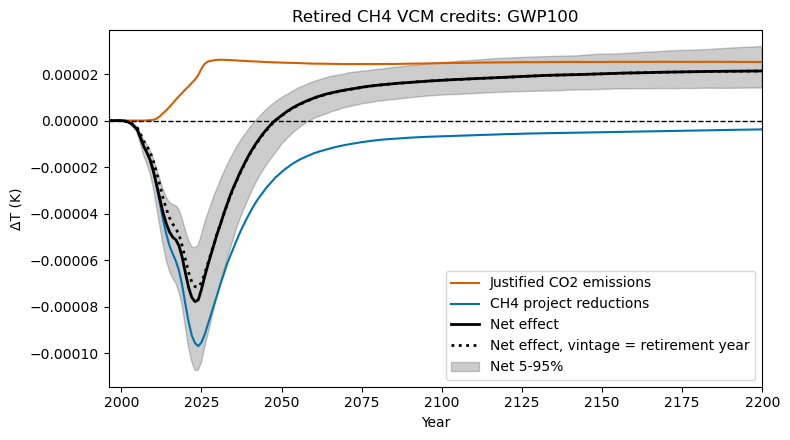

In [15]:
# ----------------------------
# plot main temperature components
# ----------------------------

plt.figure(figsize=(8, 4.5))
plt.plot(years, temperature["emissions_only"], color="#D55E00", label="Justified CO2 emissions")
plt.plot(years, temperature["projects_only"], color="#0072B2", label="CH4 project reductions")
net_line, = plt.plot(years, temperature["net_program"], color="black", linewidth=2,
    label="Net effect")
plt.plot(years, old_timing_temperature, color="black", linestyle=":", linewidth=2,
    label="Net effect, vintage = retirement year")
plt.fill_between(years, lower_net_p05, lower_net_p95, color="black", alpha=0.2, label="Net 5-95%")
plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlim(ANALYSIS_START, END_YEAR)
plt.xlabel("Year")
plt.ylabel("ΔT (K)")
plt.title("Retired CH4 VCM credits: GWP100")
plt.legend()
plt.tight_layout()
plt.show()

### Lower- and upper-bound methane estimates

The lower and upper scenarios differ in the set of retired credits attributed to methane-associated mitigation. In both cases, project cooling is assigned by credit vintage and justified CO2 warming by actual retirement year.

The upper-bound scenario contains substantially more credited mitigation than the lower bound but has a similar temporal distribution. As a result, it primarily changes the magnitude of cooling and subsequent warming rather than strongly shifting the crossover year.

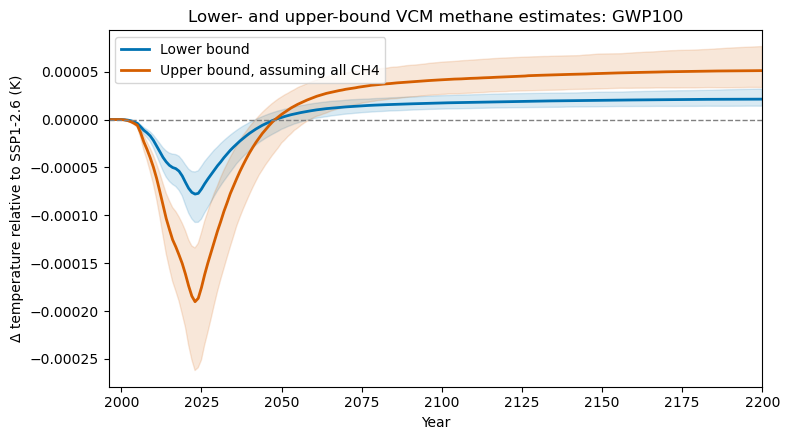

In [9]:
# ----------------------------
# compare lower- and upper-bound net effects
# ----------------------------

plt.figure(figsize=(8, 4.5))

plt.plot(years, temperature["net_program"], color="#0072B2", linewidth=2,
    label="Lower bound")
plt.fill_between(years, lower_net_p05, lower_net_p95,
    color="#0072B2", alpha=0.15)

plt.plot(years, upper_net_temperature, color="#D55E00", linewidth=2,
    label="Upper bound, assuming all CH4")
plt.fill_between(years, upper_net_p05, upper_net_p95,
    color="#D55E00", alpha=0.15)

plt.axhline(0, color="0.5", linestyle="--", linewidth=1)
plt.xlim(ANALYSIS_START, END_YEAR)
plt.xlabel("Year")
plt.ylabel("Δ temperature relative to SSP1-2.6 (K)")
plt.title("Lower- and upper-bound VCM methane estimates: GWP100")
plt.legend()
plt.tight_layout()
plt.show()

## 05 - Temperature metrics and crossover uncertainty

The crossover is the first transition from a net cooling effect to a net warming effect after the start of the VCM analysis period, with linear interpolation between annual time steps. The central values below are calculated from the median paired ensemble trajectory.

In [10]:
# ----------------------------
# temperature metrics
# ----------------------------

def crossover_year(years, temp, start=ANALYSIS_START):
    years = np.asarray(years)
    temp = np.asarray(temp)
    mask = years >= start
    y, t = years[mask], temp[mask]
    idx = np.where((t[:-1] < 0) & (t[1:] >= 0))[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    return y[i] - t[i] * (y[i + 1] - y[i]) / (t[i + 1] - t[i])

def temp_metrics(years, temp):
    mask = np.asarray(years) >= ANALYSIS_START
    y, t = np.asarray(years)[mask], np.asarray(temp)[mask]
    return {
        "crossover_year": crossover_year(y, t),
        "peak_cooling_k": t.min(),
        "peak_cooling_year": y[np.argmin(t)],
        "peak_warming_k": t.max(),
        "peak_warming_year": y[np.argmax(t)],
        "integrated_k_year": np.trapz(t, y),
        "temp_2050_k": np.interp(2050, y, t),
        "temp_2100_k": np.interp(2100, y, t),
        "temp_2200_k": np.interp(2200, y, t),
    }

central_metrics = pd.DataFrame([
    temp_metrics(years, temperature["net_program"]),
    temp_metrics(years, upper_net_temperature),
    temp_metrics(years, old_timing_temperature),
], index=[
    "Lower bound",
    "Upper bound, assuming all CH4",
    "Lower bound, vintage = retirement year",])

display(central_metrics.round(8))

,crossover_year,peak_cooling_k,peak_cooling_year,peak_warming_k,peak_warming_year,integrated_k_year,temp_2050_k,temp_2100_k,temp_2200_k
Lower bound,2047.928689,-0.000078,2023.0,0.000021,2199.0,0.001104,0.000002,0.000017,0.000021
"Upper bound, assuming all CH4",2047.955863,-0.000190,2023.0,0.000051,2199.0,0.002615,0.000005,0.000042,0.000051
"Lower bound, vintage = retirement year",2048.113923,-0.000072,2024.0,0.000021,2199.0,0.001195,0.000002,0.000017,0.000021


In [11]:
# ----------------------------
# ensemble uncertainty in summary metrics
# ----------------------------

net_program_ensemble = temperature_ensemble["net_program"]

ensemble_metrics = pd.DataFrame([temp_metrics(years, net_program_ensemble.sel(config=config).values)
    for config in net_program_ensemble.config.values])

ensemble_summary = pd.DataFrame({
    "median": ensemble_metrics.median(),
    "p05": ensemble_metrics.quantile(0.05),
    "p95": ensemble_metrics.quantile(0.95),})

crossovers = ensemble_metrics["crossover_year"].dropna().values
print(f"Median-trajectory crossover: {crossover_year(years, temperature['net_program']):.1f}")
print(f"Ensemble crossover distribution: {np.median(crossovers):.1f} ± {np.std(crossovers, ddof=1):.1f} years (median ± SD)")
print(f"Old-timing crossover: {crossover_year(years, old_timing_temperature):.1f}")
display(ensemble_summary.round(8))

Median-trajectory crossover: 2047.9
Ensemble crossover distribution: 2047.9 ± 5.4 years (median ± SD)
Old-timing crossover: 2048.1


,median,p05,p95
crossover_year,2047.920434,2041.946982,2058.904093
peak_cooling_k,-0.000078,-0.000108,-0.000055
peak_cooling_year,2023.000000,2023.000000,2024.000000
peak_warming_k,0.000021,0.000014,0.000032
peak_warming_year,2200.000000,2105.000000,2200.000000
integrated_k_year,0.001070,0.000072,0.002015
temp_2050_k,0.000002,-0.000010,0.000010
temp_2100_k,0.000017,0.000011,0.000025
temp_2200_k,0.000021,0.000014,0.000032


## 06 - GWP and GTP sensitivity tests

These sensitivity tests use the **same Hughes-matched 841-member FaIR configuration** as the primary analysis. Only the conversion from retired tCO2e credits to physical CH4 project reductions changes. The number of retired credits, and therefore the associated justified CO2 emissions, remains unchanged.

Each sensitivity result is reported as the median of the 841 paired `net_program - SSP1-2.6` temperature responses.

In [12]:
# ----------------------------
# run equivalency-metric sensitivity tests
# ----------------------------

sensitivity = {}

for metric, flux in fluxes.items():
    print(f"Running {metric}...")
    f_metric = run_program_fair(flux, scenarios=("net_program",), progress=False)
    response = (f_metric.temperature.sel(scenario="net_program", layer=0) - f_metric.temperature.sel(scenario=BASELINE_SCENARIO, layer=0))
    median_temp = response.median("config").values
    sensitivity[metric] = {"temperature": median_temp, "metrics": temp_metrics(years, median_temp),}

sensitivity_summary = pd.DataFrame({metric: result["metrics"]
    for metric, result in sensitivity.items()}).T

display(sensitivity_summary)

Running GWP100...
Running GWP20...
Running GWP500...
Running GTP20...
Running GTP50...
Running GTP100...


,crossover_year,peak_cooling_k,peak_cooling_year,peak_warming_k,peak_warming_year,integrated_k_year,temp_2050_k,temp_2100_k,temp_2200_k
GWP100,2047.928689,-0.000078,2023.0,0.000021,2199.0,0.001104,0.000002,0.000017,0.000021
GWP20,2028.768434,-0.000013,2022.0,0.000024,2198.0,0.003426,0.000017,0.000022,0.000024
GWP500,2094.222618,-0.000307,2024.0,0.000011,2200.0,-0.006957,-0.000049,0.000001,0.000011
GTP20,2032.472103,-0.000021,2022.0,0.000024,2194.0,0.003148,0.000015,0.000022,0.000024
GTP50,2063.630559,-0.000167,2024.0,0.000017,2200.0,-0.002072,-0.000018,0.000011,0.000017
GTP100,NaN,-0.000635,2024.0,0.000000,1996.0,-0.018299,-0.000124,-0.000022,-0.000001


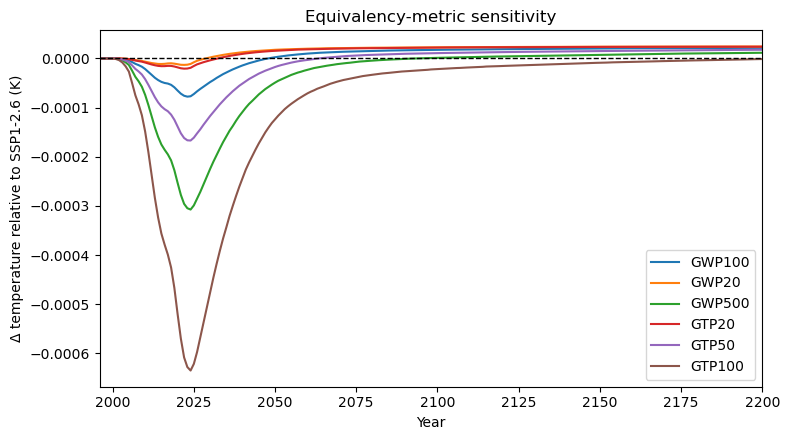

In [13]:
# ----------------------------
# plot metric sensitivity
# ----------------------------

plt.figure(figsize=(8, 4.5))

for metric, result in sensitivity.items():
    plt.plot(years, result["temperature"], label=metric)

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlim(ANALYSIS_START, END_YEAR)
plt.xlabel("Year")
plt.ylabel("Δ temperature relative to SSP1-2.6 (K)")
plt.title("Equivalency-metric sensitivity")
plt.legend()
plt.tight_layout()
plt.show()